# Dynamical Systems View of the FTTL Feedback Loop

**Paper**: Veprikov et al. (2024) *A Mathematical Model of the Hidden Feedback Loop Effect in Machine Learning Systems* (p29)

The paper models repeated machine learning as a discrete dynamical system:
$$f_{t+1}(x) = D_t(f_t(x))$$
where $f_t$ is the **probability density of the data distribution** at step $t$.

**FTTL mapping:**
- $f_t(x)$ = KDE of model score distribution in quarter $t$
- $D_t$ = the retraining operator (SFP contamination: scrapped claims → forced label=1)
- **Positive feedback loop** (Theorem 3): $f_t \to \delta$ (delta function — scores concentrate near 1)
- **Negative / dispersing**: $f_t \to \zeta$ (zero distribution — scores spread flat)

**Experiments in this notebook:**
| ID | Method | p29 reference |
|---|---|---|
| E1 | Score KDE evolution over quarters | Section 5.4, Fig 4–5 |
| E2 | $\psi_t$ trajectory (density mass near threshold) | Theorem 3 |
| E3 | D'Agostino-Pearson normality breakdown | Section 5.3 |
| E4 | Even-moment decay analysis | Lemma 1 |
| E5 | Autonomy test — is $\psi_t$ a power law? | Theorem 4 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression

THRESHOLD = 0.872  # FTTL scrap decision threshold
KAPPA = 0.05       # neighbourhood radius for ψ_t integral (p29 eq. 5)

DATA_PATH = '../src/data/synthetic/csv/claims_all.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['claim_date'])
df['quarter'] = df['claim_date'].dt.to_period('Q')
quarters = sorted(df['quarter'].unique())
T = len(quarters)  # 36 time steps

print(f'Loaded {len(df):,} claims across {T} quarters ({quarters[0]} → {quarters[-1]})')

Loaded 70,000 claims across 36 quarters (2016Q1 → 2024Q4)


---
## E1 — Score Distribution Evolution: $f_t$ Visualisation

**p29 analogy**: Fig. 4–5 show $f_t(0)$ and $\int_{-\kappa}^{\kappa} f_t(x)dx$ converging to either $\delta$ or $\zeta$.  
**Here**: we plot the KDE of `model_v1_score` (deployed score) over quarters.  
If SFP is operating, the right tail (scores near 1) should grow over time — the distribution *concentrates*.

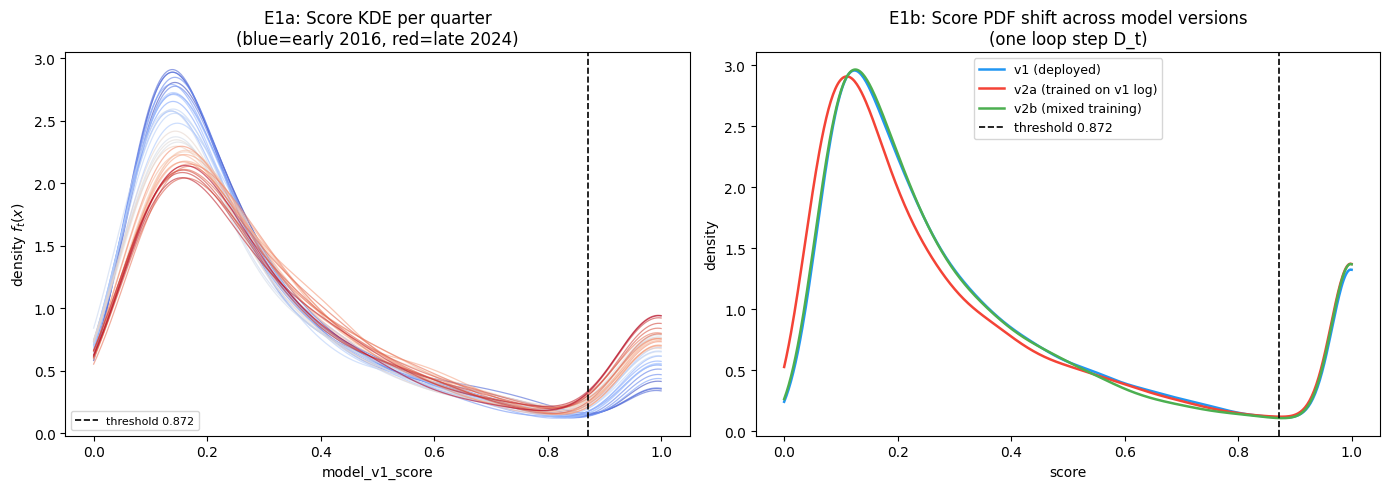

Saved e1_score_kde_evolution.png


In [2]:
score_col = 'model_v1_score'
x_grid = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: all quarters overlaid (colour = time, blue→red) ---
ax = axes[0]
colors = cm.coolwarm(np.linspace(0, 1, T))

for i, q in enumerate(quarters):
    scores = df[df['quarter'] == q][score_col].dropna().values
    kde = gaussian_kde(scores, bw_method='silverman')
    ax.plot(x_grid, kde(x_grid), color=colors[i], alpha=0.6, lw=0.9)

ax.axvline(THRESHOLD, color='black', lw=1.2, ls='--', label=f'threshold {THRESHOLD}')
ax.set_xlabel('model_v1_score')
ax.set_ylabel('density $f_t(x)$')
ax.set_title('E1a: Score KDE per quarter\n(blue=early 2016, red=late 2024)')
ax.legend(fontsize=8)

# --- Right: v1 vs v2a comparison (the "one loop step") ---
ax2 = axes[1]
for col, label, color in [
    ('model_v1_score', 'v1 (deployed)', '#2196F3'),
    ('model_v2a_score', 'v2a (trained on v1 log)', '#F44336'),
    ('model_v2b_score', 'v2b (mixed training)', '#4CAF50'),
]:
    scores = df[col].dropna().values
    kde = gaussian_kde(scores, bw_method='silverman')
    ax2.plot(x_grid, kde(x_grid), label=label, color=color, lw=1.8)

ax2.axvline(THRESHOLD, color='black', lw=1.2, ls='--', label=f'threshold {THRESHOLD}')
ax2.set_xlabel('score')
ax2.set_ylabel('density')
ax2.set_title('E1b: Score PDF shift across model versions\n(one loop step D_t)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('e1_score_kde_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved e1_score_kde_evolution.png')

---
## E2 — $\psi_t$ Trajectory

**p29 (eq. 5)**: $\psi_t = f_t(0)$ (PDF at residual=0). For FTTL (classification):  
$$\psi_t = \int_{\theta - \kappa}^{\theta + \kappa} f_t(x)\,dx$$  
where $\theta = 0.872$ (decision threshold), $\kappa = 0.05$.  

- **$\psi_t \to \infty$** → $f_t \to \delta$ → **positive feedback loop** (scores pile up near threshold)  
- **$\psi_t \to 0$** → $f_t \to \zeta$ → scores disperse (dispersive loop)

We also track $\psi_t^{\text{mass}}$ = scrap rate per quarter as a simpler proxy.

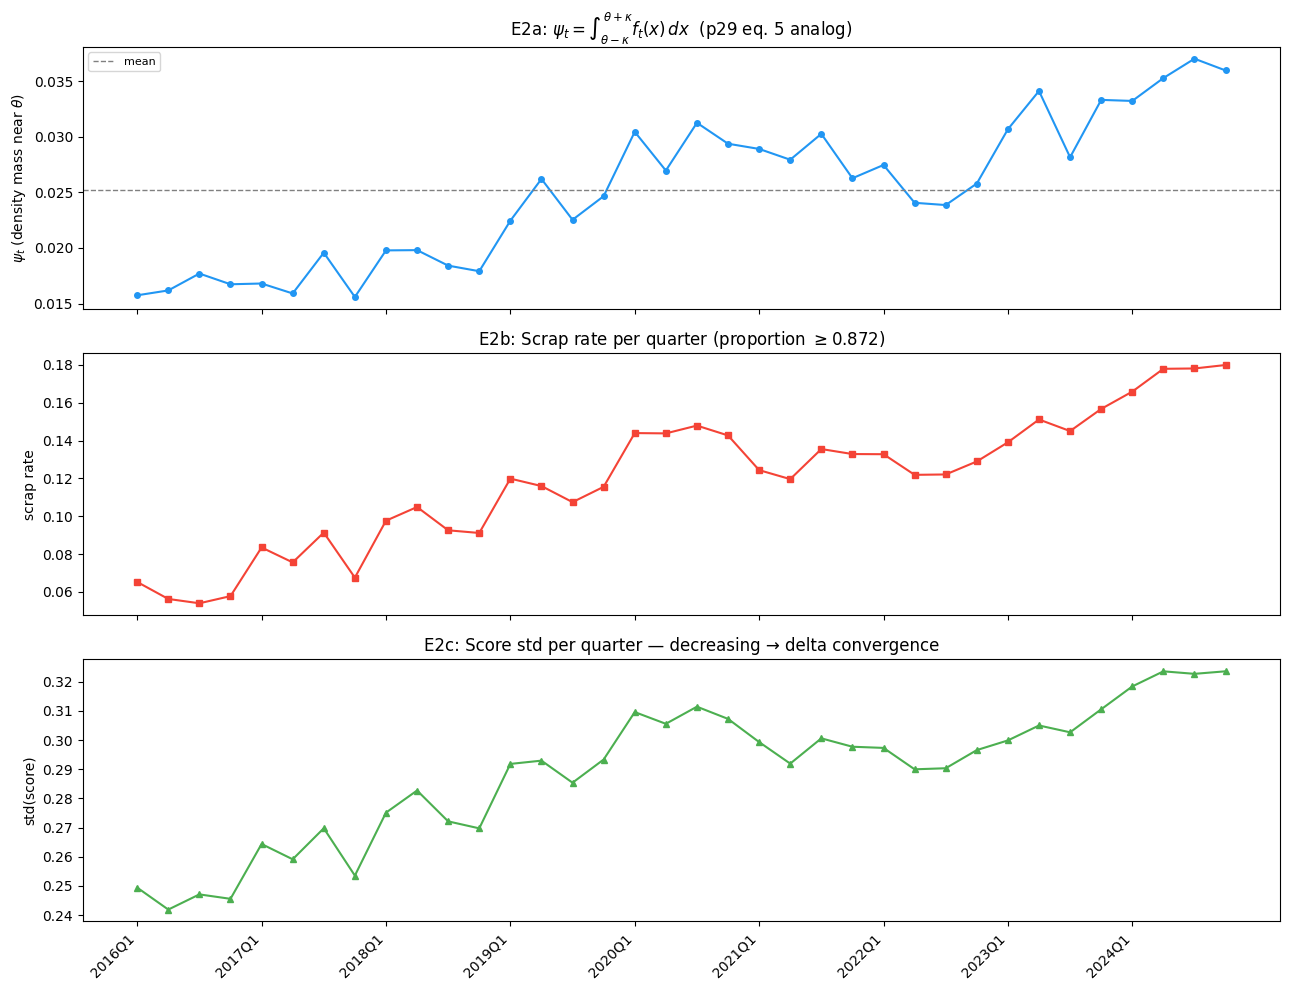

ψ_t range: [0.0156, 0.0370]
Scrap rate: 0.054 → 0.180
Score std trend: 0.2494 → 0.3236  (decrease = concentration)


In [3]:
psi_density = []  # KDE density integral near threshold
psi_scrap   = []  # scrap rate (proportion scored >= threshold)
psi_std     = []  # std of score distribution per quarter
quarter_labels = []

for q in quarters:
    sub = df[df['quarter'] == q]
    scores = sub['model_v1_score'].dropna().values

    # KDE-based ψ_t: integrate density in [θ-κ, θ+κ]
    kde = gaussian_kde(scores, bw_method='silverman')
    x_window = np.linspace(THRESHOLD - KAPPA, THRESHOLD + KAPPA, 200)
    psi_density.append(np.trapezoid(kde(x_window), x_window))

    # Scrap rate proxy
    psi_scrap.append((scores >= THRESHOLD).mean())

    # Std of score distribution
    psi_std.append(scores.std())

    quarter_labels.append(str(q))

t = np.arange(T)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(t, psi_density, 'o-', color='#2196F3', ms=4, lw=1.5)
axes[0].set_ylabel(r'$\psi_t$ (density mass near $\theta$)')
axes[0].set_title(r'E2a: $\psi_t = \int_{\theta-\kappa}^{\theta+\kappa} f_t(x)\,dx$  (p29 eq. 5 analog)')
axes[0].axhline(np.mean(psi_density), color='gray', ls='--', lw=1, label='mean')
axes[0].legend(fontsize=8)

axes[1].plot(t, psi_scrap, 's-', color='#F44336', ms=4, lw=1.5)
axes[1].set_ylabel('scrap rate')
axes[1].set_title(r'E2b: Scrap rate per quarter (proportion $\geq 0.872$)')

axes[2].plot(t, psi_std, '^-', color='#4CAF50', ms=4, lw=1.5)
axes[2].set_ylabel('std(score)')
axes[2].set_title('E2c: Score std per quarter — decreasing → delta convergence')

xtick_idx = list(range(0, T, 4))
axes[2].set_xticks(xtick_idx)
axes[2].set_xticklabels([quarter_labels[i] for i in xtick_idx], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('e2_psi_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ψ_t range: [{min(psi_density):.4f}, {max(psi_density):.4f}]')
print(f'Scrap rate: {min(psi_scrap):.3f} → {max(psi_scrap):.3f}')
print(f'Score std trend: {psi_std[0]:.4f} → {psi_std[-1]:.4f}  (decrease = concentration)')

---
## E3 — Normality Breakdown Test

**p29 (Section 5.3)**: D'Agostino-Pearson test applied to prediction error $y_i - y'_i$ per quarter.  
As the feedback loop progresses, normality breaks down (p-value drops below 0.05).  

**FTTL mapping**: apply normality test to **model score** per quarter.  
Scores begin approximately normal (spread across [0,1]); if SFP concentrates them, the distribution
becomes non-normal (heavy right tail, bimodal, etc.).

We test both `model_v1_score` and `model_v2a_score - model_v1_score` (the cross-version score shift).

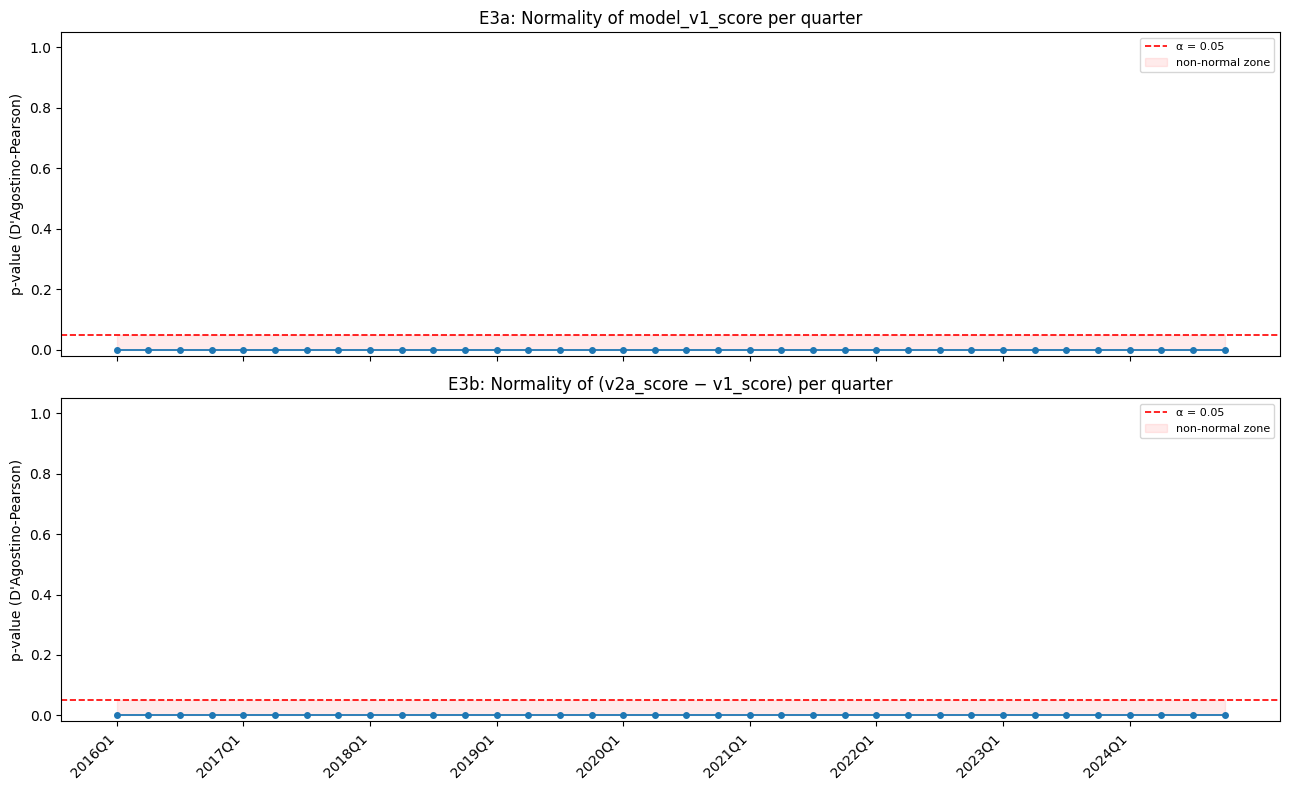

v1 score: 36/36 quarters reject normality (p < 0.05)
score diff: 36/36 quarters reject normality


In [4]:
normality_v1   = []  # p-value of D'Agostino-Pearson on v1 score per quarter
normality_diff = []  # p-value on (v2a_score - v1_score) per quarter

for q in quarters:
    sub = df[df['quarter'] == q]

    s1 = sub['model_v1_score'].dropna().values
    _, p1 = stats.normaltest(s1)
    normality_v1.append(p1)

    diff = (sub['model_v2a_score'] - sub['model_v1_score']).dropna().values
    _, pd_ = stats.normaltest(diff)
    normality_diff.append(pd_)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
alpha = 0.05

for ax, pvals, title in [
    (axes[0], normality_v1,   'E3a: Normality of model_v1_score per quarter'),
    (axes[1], normality_diff, 'E3b: Normality of (v2a_score − v1_score) per quarter'),
]:
    ax.plot(t, pvals, 'o-', ms=4, lw=1.3)
    ax.axhline(alpha, color='red', ls='--', lw=1.2, label=f'α = {alpha}')
    ax.fill_between(t, 0, alpha, alpha=0.08, color='red', label='non-normal zone')
    ax.set_ylabel('p-value (D\'Agostino-Pearson)')
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8)

axes[1].set_xticks(xtick_idx)
axes[1].set_xticklabels([quarter_labels[i] for i in xtick_idx], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('e3_normality_test.png', dpi=150, bbox_inches='tight')
plt.show()

non_normal_v1   = sum(1 for p in normality_v1 if p < alpha)
non_normal_diff = sum(1 for p in normality_diff if p < alpha)
print(f'v1 score: {non_normal_v1}/{T} quarters reject normality (p < {alpha})')
print(f'score diff: {non_normal_diff}/{T} quarters reject normality')

---
## E4 — Even-Moment Decay Analysis (Lemma 1)

**p29 (Lemma 1)**: If the system satisfies Theorem 3 and $\psi_t \to \infty$,  
then **all even moments** $\nu_{2k}$ of $y_i - y'_i$ **decrease** at rate $\geq \psi_t^{-2k}$.  
Decreasing variance (2nd moment) = prediction errors concentrating near 0 = **positive feedback loop**.

**FTTL mapping**: track the 2nd and 4th moments of the **cross-version score shift**  
$(v_{2a} - v_1)$ per quarter. If moments decrease over time → loop is tightening.

We also track moments of $(\text{observed outcome} - v_1\text{ score})$ as a residual proxy.

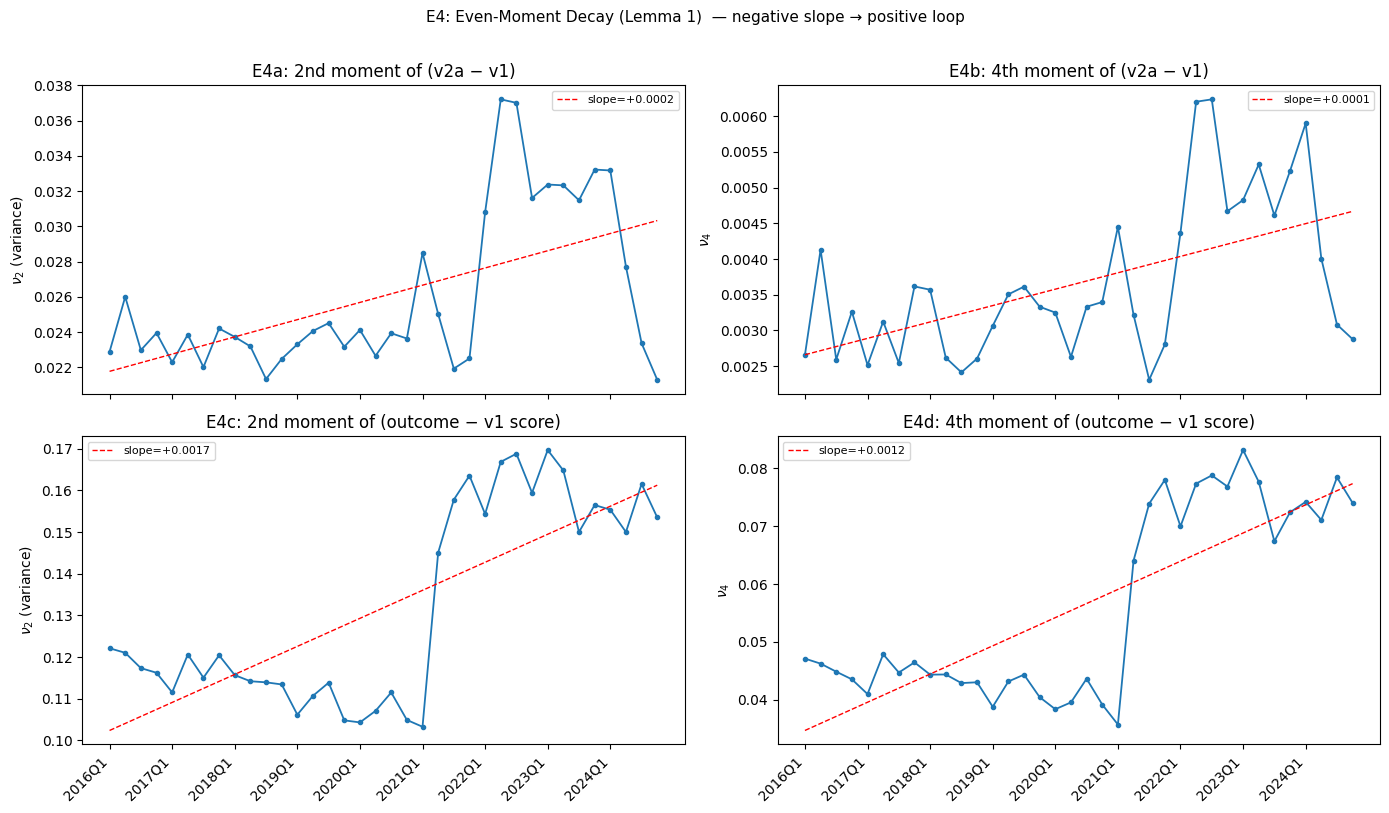

Slope of ν₂(v2a-v1): +0.00024  ↑ no concentration
Slope of ν₂(residual): +0.00168  ↑ no concentration


In [5]:
m2_shift   = []  # 2nd moment (variance) of (v2a - v1)
m4_shift   = []  # 4th central moment of (v2a - v1)
m2_resid   = []  # 2nd moment of (observed_outcome - v1_score)
m4_resid   = []

for q in quarters:
    sub = df[df['quarter'] == q]

    shift = (sub['model_v2a_score'] - sub['model_v1_score']).dropna().values
    m2_shift.append(np.mean(shift**2))
    m4_shift.append(np.mean(shift**4))

    # residual: label - score (model error proxy, no oracle needed)
    resid = (sub['model_v1_observed_outcome'] - sub['model_v1_score']).dropna().values
    m2_resid.append(np.mean(resid**2))
    m4_resid.append(np.mean(resid**4))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, vals, ylabel, title in [
    (axes[0,0], m2_shift, r'$\nu_2$ (variance)', 'E4a: 2nd moment of (v2a − v1)'),
    (axes[0,1], m4_shift, r'$\nu_4$', 'E4b: 4th moment of (v2a − v1)'),
    (axes[1,0], m2_resid, r'$\nu_2$ (variance)', 'E4c: 2nd moment of (outcome − v1 score)'),
    (axes[1,1], m4_resid, r'$\nu_4$', 'E4d: 4th moment of (outcome − v1 score)'),
]:
    ax.plot(t, vals, 'o-', ms=3, lw=1.3)
    # simple linear trend line
    z = np.polyfit(t, vals, 1)
    ax.plot(t, np.polyval(z, t), 'r--', lw=1, label=f'slope={z[0]:+.4f}')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

for ax in axes[1]:
    ax.set_xticks(xtick_idx)
    ax.set_xticklabels([quarter_labels[i] for i in xtick_idx], rotation=45, ha='right')

fig.suptitle('E4: Even-Moment Decay (Lemma 1)  — negative slope → positive loop', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('e4_moment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

slope_m2_shift, *_ = np.polyfit(t, m2_shift, 1)
slope_m2_resid, *_ = np.polyfit(t, m2_resid, 1)
print(f'Slope of ν₂(v2a-v1): {slope_m2_shift:+.5f}  {"↓ positive loop signal" if slope_m2_shift < 0 else "↑ no concentration"}')
print(f'Slope of ν₂(residual): {slope_m2_resid:+.5f}  {"↓ positive loop signal" if slope_m2_resid < 0 else "↑ no concentration"}')

---
## E5 — Autonomy Test (Theorem 4)

**p29 (Theorem 4)**: A dynamical system $f_{t+1} = D(f_t)$ (autonomous — operator unchanged over time)  
if and only if $\psi_{\tau+\kappa} = \psi_\tau \cdot \psi_\kappa$, i.e. $\psi_t = a^t$ for some $a > 0$.

To test: fit $\log(\psi_t) = t \cdot \log(a) + c$ via linear regression.  
- **High $R^2$** → $\psi_t$ follows a power law → system is **autonomous** (stable loop, constant D_t)  
- **Low $R^2$** → system is **non-autonomous** (D_t changes over time — e.g., operational changes, mix shifts)

ψ_t (density near θ): R²=0.8157, a=1.023500, c=-4.1229
  → ψ_t ≈ 0.0162 × 1.023500^t
  → a > 1: ψ_t diverges → delta function convergence (positive loop)

ψ_t (scrap rate): R²=0.8085, a=1.028955, c=-2.6773
  → ψ_t ≈ 0.0687 × 1.028955^t
  → a > 1: ψ_t diverges → delta function convergence (positive loop)

ψ_t (score std): R²=0.7832, a=1.006958, c=-1.3665
  → ψ_t ≈ 0.2550 × 1.006958^t
  → a > 1: ψ_t diverges → delta function convergence (positive loop)


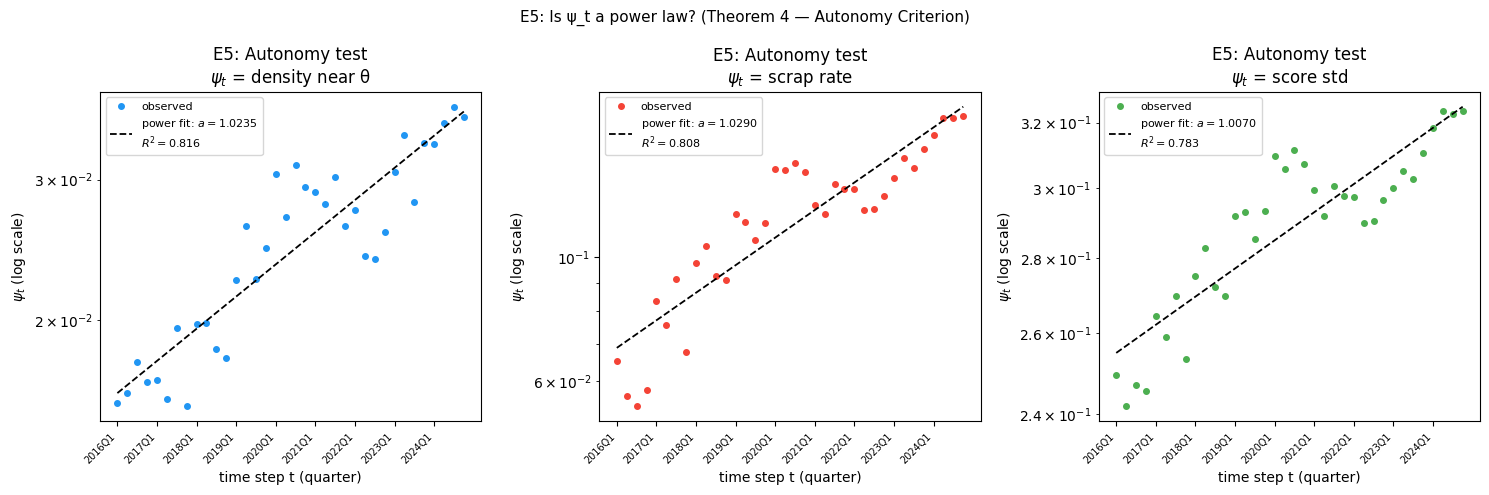

In [6]:
def autonomy_test(psi_vals, label):
    """Fit log(ψ_t) ~ t and return (R², a, c). Theorem 4 of p29."""
    psi = np.array(psi_vals)
    # clip to avoid log(0)
    psi = np.clip(psi, 1e-9, None)
    log_psi = np.log(psi)
    X = t.reshape(-1, 1).astype(float)

    reg = LinearRegression().fit(X, log_psi)
    r2 = reg.score(X, log_psi)
    log_a = reg.coef_[0]
    a = np.exp(log_a)
    c = reg.intercept_

    print(f'{label}: R²={r2:.4f}, a={a:.6f}, c={c:.4f}')
    print(f'  → ψ_t ≈ {np.exp(c):.4f} × {a:.6f}^t')
    if a > 1:
        print(f'  → a > 1: ψ_t diverges → delta function convergence (positive loop)')
    else:
        print(f'  → a < 1: ψ_t → 0 → zero distribution (dispersive)')
    return r2, a, c, reg

r2_density, a_density, c_density, reg_density = autonomy_test(psi_density, 'ψ_t (density near θ)')
print()
r2_scrap, a_scrap, c_scrap, reg_scrap = autonomy_test(psi_scrap, 'ψ_t (scrap rate)')
print()
r2_std, a_std, c_std, reg_std = autonomy_test(psi_std, 'ψ_t (score std)')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, psi_vals, reg, r2, a, c, label, color in [
    (axes[0], psi_density, reg_density, r2_density, a_density, c_density, 'density near θ', '#2196F3'),
    (axes[1], psi_scrap,   reg_scrap,   r2_scrap,   a_scrap,   c_scrap,   'scrap rate',     '#F44336'),
    (axes[2], psi_std,     reg_std,     r2_std,     a_std,     c_std,     'score std',      '#4CAF50'),
]:
    psi = np.clip(np.array(psi_vals), 1e-9, None)
    ax.semilogy(t, psi, 'o', ms=4, color=color, label='observed')
    fitted = np.exp(c) * a**t
    ax.semilogy(t, fitted, '--', color='black', lw=1.3,
                label=f'power fit: $a={a:.4f}$\n$R^2={r2:.3f}$')
    ax.set_xlabel('time step t (quarter)')
    ax.set_ylabel(r'$\psi_t$ (log scale)')
    ax.set_title(f'E5: Autonomy test\n$\psi_t$ = {label}')
    ax.legend(fontsize=8)
    ax.set_xticks(xtick_idx)
    ax.set_xticklabels([quarter_labels[i] for i in xtick_idx], rotation=45, ha='right', fontsize=7)

plt.suptitle('E5: Is ψ_t a power law? (Theorem 4 — Autonomy Criterion)', fontsize=11)
plt.tight_layout()
plt.savefig('e5_autonomy_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E6 — Cross-Version Score Shift: One Step of $D_t$

The paper's D_t maps one PDF to the next. Here we directly measure what happens to the score
distribution across model versions (v1 → v2a → v2b), treating each version as one time step.

We use the **Kolmogorov-Smirnov test** to quantify how much the distribution shifted,
and inspect whether v2a (trained on SFP-contaminated labels) shifts more than v2b (cleaner training).

Kolmogorov-Smirnov test vs v1:
  v1 vs v2a: KS=0.0568, p=1.920e-98, mean_shift=-0.0063
  v1 vs v2b: KS=0.0098, p=2.344e-03, mean_shift=-0.0028
  v1 vs v3a: KS=0.1130, p=0.000e+00, mean_shift=-0.0112

Even moments per version:
version      mean       std          ν₂            ν₄      skew      kurt
    v1    0.3493    0.2916     0.20703       0.14208    1.2004    0.2280
   v2a    0.3430    0.3037     0.20984       0.14944    1.1576    0.0637
   v2b    0.3465    0.2938     0.20638       0.14418    1.2288    0.2734
   v3a    0.3381    0.3141     0.21292       0.15439    1.0945   -0.1377


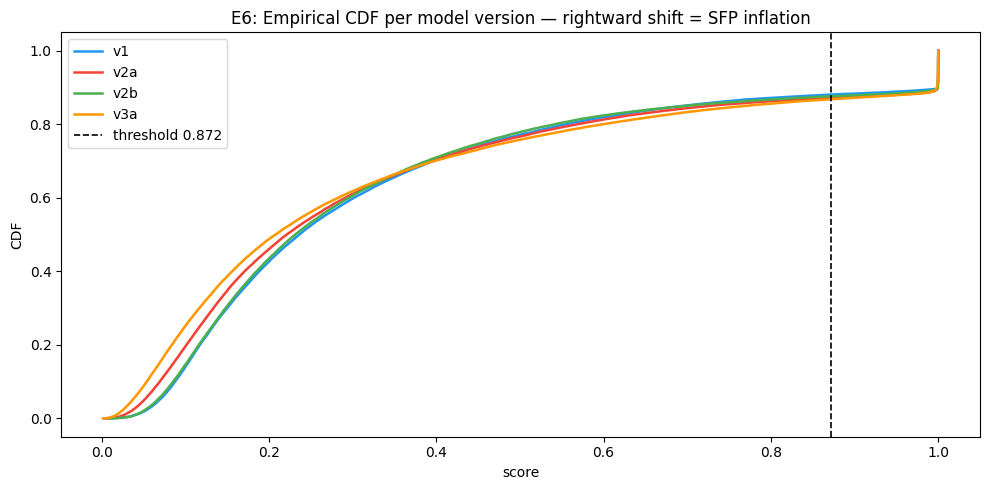

In [7]:
score_versions = {
    'v1':  df['model_v1_score'].dropna().values,
    'v2a': df['model_v2a_score'].dropna().values,
    'v2b': df['model_v2b_score'].dropna().values,
    'v3a': df['model_v3a_score'].dropna().values,
}

# Pairwise KS test: how different is each version from v1?
print('Kolmogorov-Smirnov test vs v1:')
for vname, scores in score_versions.items():
    if vname == 'v1':
        continue
    ks_stat, ks_p = stats.ks_2samp(score_versions['v1'], scores)
    mean_shift = scores.mean() - score_versions['v1'].mean()
    print(f'  v1 vs {vname}: KS={ks_stat:.4f}, p={ks_p:.3e}, mean_shift={mean_shift:+.4f}')

print()

# Per-version moments (Lemma 1 check across versions)
print('Even moments per version:')
print(f'{"version":>6}  {"mean":>8}  {"std":>8}  {"ν₂":>10}  {"ν₄":>12}  {"skew":>8}  {"kurt":>8}')
for vname, scores in score_versions.items():
    mu2 = np.mean(scores**2)
    mu4 = np.mean(scores**4)
    print(f'{vname:>6}  {scores.mean():>8.4f}  {scores.std():>8.4f}  {mu2:>10.5f}  {mu4:>12.5f}  {stats.skew(scores):>8.4f}  {stats.kurtosis(scores):>8.4f}')

# Plot: CDF overlay to visualise distributional shift
fig, ax = plt.subplots(figsize=(10, 5))
colors_v = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
for (vname, scores), c in zip(score_versions.items(), colors_v):
    sorted_s = np.sort(scores)
    cdf = np.arange(1, len(sorted_s)+1) / len(sorted_s)
    ax.plot(sorted_s, cdf, label=vname, color=c, lw=1.8)

ax.axvline(THRESHOLD, color='black', ls='--', lw=1.2, label=f'threshold {THRESHOLD}')
ax.set_xlabel('score')
ax.set_ylabel('CDF')
ax.set_title('E6: Empirical CDF per model version — rightward shift = SFP inflation')
ax.legend()
plt.tight_layout()
plt.savefig('e6_version_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Experiment | What to look for | Positive loop signal |
|---|---|---|
| E1 KDE evolution | Right-tail growth over quarters | Red curves higher near 1 |
| E2 ψ_t trajectory | ψ_t trend over time | ψ_t increasing OR scrap rate increasing |
| E3 Normality | p-value dropping below 0.05 | Normality breaks down post-model deployment |
| E4 Moments | Slopes of ν₂, ν₄ over time | Negative slope = concentration |
| E5 Autonomy | R² of log-linear fit to ψ_t | High R² + a > 1 = autonomous positive loop |
| E6 Version CDF | Rightward CDF shift across versions | v2a further right than v2b |

**p29 Theorem 3 verdict for FTTL**: if $\psi_t$ (from E2) increases monotonically over time,
the score distribution is converging toward a Dirac delta — a confirmed positive feedback loop.